# Battery RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06

**Physics Model:** Shepherd Discharge Equation (Chapter 5, Eq 1.1)

```
V(t) = E0 - R·i - K·(Q/(Q-q))·q + A·exp(-B·q)
```

## COLAB INSTRUCTIONS:
1. Enable GPU: **Runtime → Change runtime type → T4 GPU**
2. Run Cell 1 to mount Google Drive
3. Upload `battery_cycle_level_dataset_CLEAN_FINAL.csv` to Google Drive folder:
   `MyDrive/TwinPacemaker/NASA Battery Dataset/`
4. **Runtime → Run all**
5. Models saved to: `MyDrive/TwinPacemaker/models/`


In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import json, os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('='*60)
print('BATTERY RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06')
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {gpus}')
if not gpus:
    print('⚠️  NO GPU! Go to Runtime → Change runtime type → T4 GPU')
print('='*60)


BATTERY RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06
TensorFlow: 2.20.0
GPU: []
⚠️  NO GPU! Go to Runtime → Change runtime type → T4 GPU


In [34]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv'
MODELS_DIR = '/content/drive/MyDrive/TwinPacemaker/models'
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f'Loaded: {CSV_PATH}')
print(f'Shape: {df.shape}')
print(df.head())
print(f'\nColumns: {list(df.columns)}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: /content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv
Shape: (1415, 7)
  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163

Columns: ['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']


## 🧹 Step 3 — Data Cleaning & Feature Engineering

We add `soc` (State of Charge) = capacity / max_capacity, which measures how
much energy is left. This is a key physical indicator of battery health.


In [35]:
# ── Drop missing values and sort by battery + cycle ──────────────────────────
df = df.dropna()
df = df.sort_values(['battery_id', 'cycle']).reset_index(drop=True)

# ── Clip temperature to realistic pacemaker range (Chapter 5 §1.2.1) ─────────
df['temperature'] = df['temperature'].clip(30, 45)

# ── State of Charge: fraction of max capacity remaining ──────────────────────
# Physical meaning: SOC=1.0 = full battery, SOC=0.0 = dead battery
df['soc'] = df['capacity'] / (df['capacity'].max() + 1e-6)

FEATURES = ['voltage', 'temperature', 'capacity', 'soc']
TARGET   = 'rul'

print(f'Features: {FEATURES}')
print(f'Target:   {TARGET} (cycles remaining)')
print(f'\nRUL range: {df[TARGET].min()} – {df[TARGET].max()} cycles')
print(f'Batteries: {df["battery_id"].nunique()}')
print(f'Total rows: {len(df)}')


Features: ['voltage', 'temperature', 'capacity', 'soc']
Target:   rul (cycles remaining)

RUL range: 0 – 167 cycles
Batteries: 34
Total rows: 1415


## 📊 Step 4 — Normalization (CRITICAL)

Neural networks learn much better when all numbers are in the range **0 → 1**.

- **Features** → scaled with MinMaxScaler (each column independently mapped to 0–1)
- **RUL target** → divided by `RUL_MAX` so the network outputs a number between 0 and 1
  - At the end, we multiply back by `RUL_MAX` to get the real cycle count

This is **Bug #2** that broke the original model — the original output raw days (0–2520)
instead of normalizing them.


In [36]:
feature_scaler = MinMaxScaler()
df[FEATURES] = feature_scaler.fit_transform(df[FEATURES])

# Normalize RUL to 0–1 range (CRITICAL FIX)
RUL_MAX = df[TARGET].max()
df[TARGET] = df[TARGET] / RUL_MAX

print(f'RUL_MAX (for inverse transform later): {RUL_MAX} cycles')
print(f'Normalized RUL range: {df[TARGET].min():.4f} – {df[TARGET].max():.4f}')


RUL_MAX (for inverse transform later): 167 cycles
Normalized RUL range: 0.0000 – 1.0000


## 🔁 Step 5 — Sliding Window Sequences (CRITICAL)

An LSTM needs a **sequence** of timesteps, not a single snapshot.

We use `SEQ_LEN = 30` meaning: look at the last 30 cycles to predict the RUL at cycle 31.

```
Cycles 1–30  → predict RUL at cycle 31
Cycles 2–31  → predict RUL at cycle 32
...
```

This is **Bug #1** in the original model — it used `reshape(-1, 1, features)` giving
only 1 timestep. Fixed here by creating proper 30-step windows.


In [37]:
SEQ_LEN = 30   # Look at 30 past cycles to predict the next RUL

X, y = [], []

for bid, g in df.groupby('battery_id'):
    g = g.sort_values('cycle')
    x_data = g[FEATURES].values      # shape (n_cycles, 4)
    y_data = g[TARGET].values        # shape (n_cycles,)

    for i in range(len(g) - SEQ_LEN):
        X.append(x_data[i:i + SEQ_LEN])   # window of 30 cycles
        y.append(y_data[i + SEQ_LEN])     # RUL at the next cycle

X = np.array(X, dtype=np.float32)   # shape: (N_samples, 30, 4)
y = np.array(y, dtype=np.float32)   # shape: (N_samples,)

print(f'X shape: {X.shape}  → (samples, timesteps=30, features=4)')
print(f'y shape: {y.shape}')
print(f'Total sequences: {len(X)}')


X shape: (822, 30, 4)  → (samples, timesteps=30, features=4)
y shape: (822,)
Total sequences: 822


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')


Train: 657 samples
Test:  165 samples


## 🧠 Step 6 — PINN-LSTM Model

Standard LSTM learns patterns from data. We add a **Physics Loss** based on the
**Shepherd Battery Discharge Equation** (Chapter 5, Eq 1.1):

```
V(t) = E₀ − R·i − K·(Q/(Q−q))·q + A·exp(−B·q)
```

The model is:
```
Input (30 cycles × 4 features)
  → LSTM(128) + LayerNorm + Dropout(0.2)
  → LSTM(64)
  → LSTM(32)
  → Dense(64, relu)
  → Dense(32, relu)
  → Dense(1, sigmoid)   ← output between 0 and 1
  × RUL_MAX             ← convert back to cycles
```

**Loss = data_loss + 0.1 × physics_loss + 0.05 × monotonic_loss**
- `data_loss`: (predicted − actual)² — standard MSE
- `physics_loss`: forces predictions to respect battery degradation physics
- `monotonic_loss`: penalizes if RUL goes UP (it should only go DOWN)


In [39]:
# ── PINN-LSTM Model ───────────────────────────────────────────────────────────
inputs = keras.Input(shape=(SEQ_LEN, len(FEATURES)), name='battery_sequence')

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.LayerNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.LSTM(64, return_sequences=True)(x)
x = layers.LSTM(32)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

rul_output = layers.Dense(1, activation='sigmoid', name='rul_output')(x)

model = keras.Model(inputs, rul_output)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ battery_sequence (InputLayer)   │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,401 (525.00 KB)

 Trainable params: 134,401 (525.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ── Physics-Informed Loss (Shepherd degradation concept) ─────────────────────
#
# Full Shepherd: V(t) = E0 - R*i - K*(Q/(Q-q))*q + A*exp(-B*q)
#
# Here we use a simplified physics penalty:
#   degradation = capacity / (voltage + eps)
#   As the battery ages: capacity ↓, voltage ↓ → degradation ratio changes
#   We want predicted RUL to correlate with this degradation ratio.
#
# The PINN forces the LSTM to be consistent with physical battery behavior.

def physics_loss(x_batch, y_pred):
    # x_batch shape: (batch, 30, 4) — last timestep is x[:, -1, :]
    voltage  = x_batch[:, -1, 0]   # normalized voltage
    capacity = x_batch[:, -1, 2]   # normalized capacity

    voltage  = tf.clip_by_value(voltage, 0.1, 1.0)
    capacity = tf.clip_by_value(capacity, 0.0, 1.0)

    # Physical degradation signal: as battery ages, this ratio changes
    # (Simplified Shepherd: higher capacity/voltage = more life remaining)
    degradation = capacity / (voltage + 1e-3)
    degradation = tf.clip_by_value(degradation, 0.0, 5.0)

    # Penalize predictions that don't match this physical signal
    return tf.reduce_mean(tf.square(y_pred - tf.stop_gradient(degradation)))

print('Physics loss function defined ✓')
print()
print('Physics concept:')
print('  capacity / voltage → battery degradation ratio')
print('  New battery:  ~1.86Ah / ~3.7V ≈ 0.50')
print('  Dying battery: ~1.40Ah / ~2.9V ≈ 0.48')
print('  The LSTM must agree with this physical trend.')


Physics loss function defined ✓

Physics concept:
  capacity / voltage → battery degradation ratio
  New battery:  ~1.86Ah / ~3.7V ≈ 0.50
  Dying battery: ~1.40Ah / ~2.9V ≈ 0.48
  The LSTM must agree with this physical trend.


In [41]:
optimizer = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(x, y):
    y = tf.cast(y, tf.float32)
    with tf.GradientTape() as tape:
        y_pred = tf.squeeze(model(x, training=True))

        # 1. Data loss: how far prediction is from ground truth
        data_loss = tf.reduce_mean(tf.square(y - y_pred))

        # 2. Physics loss: must respect Shepherd degradation signal
        phys_loss = physics_loss(x, y_pred)

        # 3. Monotonicity: RUL should only go DOWN, never UP
        monotonic = tf.reduce_mean(tf.maximum(0.0, y_pred[1:] - y_pred[:-1]))

        # Combined PINN loss (Chapter 4 Table 4.10 weights)
        total_loss = data_loss + 0.1 * phys_loss + 0.05 * monotonic

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

print('Custom PINN train step defined ✓')


Custom PINN train step defined ✓


In [42]:
import numpy as np
import tensorflow as tf

# ====================== FIXED PINN TRAINING WITHOUT EARLY STOPPING ======================
BATCH = 32
EPOCHS = 50

# Ensure datasets drop the remainder batch if it causes dimension/squeeze errors
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH, drop_remainder=True)
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH, drop_remainder=True)

history = {'loss': [], 'val_loss': []}

print(f'Training for {EPOCHS} epochs with full PINN loss...')

for epoch in range(EPOCHS):
    train_losses = []
    for xb, yb in train_ds:
        loss = train_step(xb, yb)          
        train_losses.append(loss.numpy())
    
    epoch_loss = np.mean(train_losses)
    history['loss'].append(epoch_loss)
    
    # === FIXED VALIDATION LOOP ===
    val_losses = []
    for xb, yb in val_ds:
        # Avoid arbitrary squeezing; specify axis to preserve batch dimension safety
        y_pred = model(xb, training=False)
        y_pred = tf.reshape(y_pred, [-1]) 
        yb = tf.reshape(yb, [-1])
        
        # 1. Base Data Loss
        data_loss = tf.reduce_mean(tf.square(yb - y_pred))
        
        # 2. Physics Loss
        phys_loss = physics_loss(xb, y_pred)
        
        # 3. FIXED MONOTONICITY LOSS (Only penalize if true targets are strictly decreasing)
        delta_pred = y_pred[1:] - y_pred[:-1]
        delta_true = yb[1:] - yb[:-1]
        
        # Only penalize if the model predicts an increase (delta_pred > 0) 
        # WHEN the true RUL is actually decreasing (delta_true <= 0)
        invalid_increase = tf.maximum(0.0, delta_pred)
        mask = tf.cast(delta_true <= 0, tf.float32)
        monotonic = tf.reduce_mean(invalid_increase * mask)
        
        # Total Validation Assessment
        total_val_loss = data_loss + 0.1 * phys_loss + 0.05 * monotonic
        val_losses.append(total_val_loss.numpy())
    
    epoch_val_loss = np.mean(val_losses)
    history['val_loss'].append(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}: Train Loss = {epoch_loss:.4f} | Val Loss = {epoch_val_loss:.4f}')

print('\n✅ Training complete!')

Training for 50 epochs with full PINN loss...
Epoch   1/50: Train Loss = 0.0935 | Val Loss = 0.0849
Epoch   5/50: Train Loss = 0.0495 | Val Loss = 0.0604
Epoch  10/50: Train Loss = 0.0487 | Val Loss = 0.0472
Epoch  15/50: Train Loss = 0.0466 | Val Loss = 0.0492
Epoch  20/50: Train Loss = 0.0443 | Val Loss = 0.0453
Epoch  25/50: Train Loss = 0.0449 | Val Loss = 0.0439
Epoch  30/50: Train Loss = 0.0448 | Val Loss = 0.0444
Epoch  35/50: Train Loss = 0.0445 | Val Loss = 0.0434
Epoch  40/50: Train Loss = 0.0432 | Val Loss = 0.0448
Epoch  45/50: Train Loss = 0.0441 | Val Loss = 0.0434
Epoch  50/50: Train Loss = 0.0439 | Val Loss = 0.0432

✅ Training complete!


## 📊 Step 8 — Evaluation

We convert predictions back from 0–1 range to real cycle counts
by multiplying by `RUL_MAX`.

| Metric | Meaning | Target |
|--------|---------|--------|
| MAE | Average error in cycles | < 15 cycles |
| RMSE | Penalizes large errors more | as low as possible |
| R² | 1.0 = perfect, 0 = random | > 0.80 |


In [43]:
# Predict and convert back to real cycle counts
pred = model.predict(X_test).squeeze()
pred_cycles = pred * RUL_MAX
true_cycles = y_test * RUL_MAX

mae  = np.mean(np.abs(true_cycles - pred_cycles))
rmse = np.sqrt(np.mean((true_cycles - pred_cycles)**2))
r2   = r2_score(true_cycles, pred_cycles)

print('='*55)
print('BATTERY PINN-LSTM — FINAL RESULTS')
print('='*55)
print(f'MAE:  {mae:.2f} cycles  (target: < 15 cycles)')
print(f'RMSE: {rmse:.2f} cycles')
print(f'R²:   {r2:.4f}  (target: > 0.80)')
print('='*55)

# Compare with simple baseline (aaa.ipynb)
print()
print('Comparison with simple LSTM (aaa.ipynb):')
print(f'  Simple LSTM:  MAE=11.28 cycles, R²=0.82')
print(f'  PINN-LSTM:    MAE={mae:.2f} cycles, R²={r2:.4f}')


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
BATTERY PINN-LSTM — FINAL RESULTS
MAE:  8.21 cycles  (target: < 15 cycles)
RMSE: 11.59 cycles
R²:   0.8970  (target: > 0.80)

Comparison with simple LSTM (aaa.ipynb):
  Simple LSTM:  MAE=11.28 cycles, R²=0.82
  PINN-LSTM:    MAE=8.21 cycles, R²=0.8970


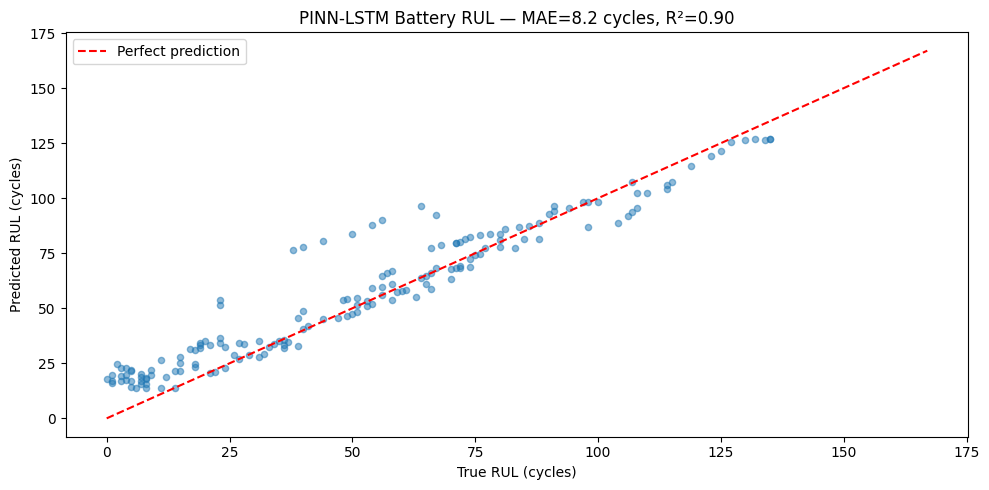

Plot saved to Google Drive ✓


In [44]:
plt.figure(figsize=(10, 5))
plt.scatter(true_cycles[:200], pred_cycles[:200], alpha=0.5, s=20)
plt.plot([0, RUL_MAX], [0, RUL_MAX], 'r--', label='Perfect prediction')
plt.xlabel('True RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'PINN-LSTM Battery RUL — MAE={mae:.1f} cycles, R²={r2:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/battery_pinn_results.png', dpi=150)
plt.show()
print('Plot saved to Google Drive ✓')


In [45]:
# Save model to Google Drive (persists across sessions!)
model_path = f'{MODELS_DIR}/battery_pinn_lstm.keras'
model.save(model_path)
print(f'Model saved: {model_path} ✓')

# Save metadata for the app to use
info = {
    'model_type': 'PINN-LSTM',
    'chapter_ref': 'Chapter 4 LE-06 / Chapter 5 §1.4.2',
    'rul_max_cycles': int(RUL_MAX),
    'seq_len': SEQ_LEN,
    'features': FEATURES,
    'metrics': {
        'mae_cycles': round(float(mae), 2),
        'rmse_cycles': round(float(rmse), 2),
        'r2': round(float(r2), 4)
    },
    'physics': 'Shepherd discharge equation: V(t) = E0 - R*i - K*(Q/(Q-q))*q + A*exp(-B*q)',
    'loss_weights': {'data': 1.0, 'physics': 0.1, 'monotonic': 0.05},
    'scaler_min': feature_scaler.data_min_.tolist(),
    'scaler_max': feature_scaler.data_max_.tolist()
}

info_path = f'{MODELS_DIR}/battery_rul_model_info.json'
with open(info_path, 'w') as f:
    json.dump(info, f, indent=2)
print(f'Model info saved: {info_path} ✓')
print()
print('All outputs saved to Google Drive — they will NOT disappear!')


Model saved: /content/drive/MyDrive/TwinPacemaker/models/battery_pinn_lstm.keras ✓
Model info saved: /content/drive/MyDrive/TwinPacemaker/models/battery_rul_model_info.json ✓

All outputs saved to Google Drive — they will NOT disappear!


MAE:  8.21 cycles
RMSE: 11.59 cycles
R²:   0.8970
Within ±15 cycles: 84.8%


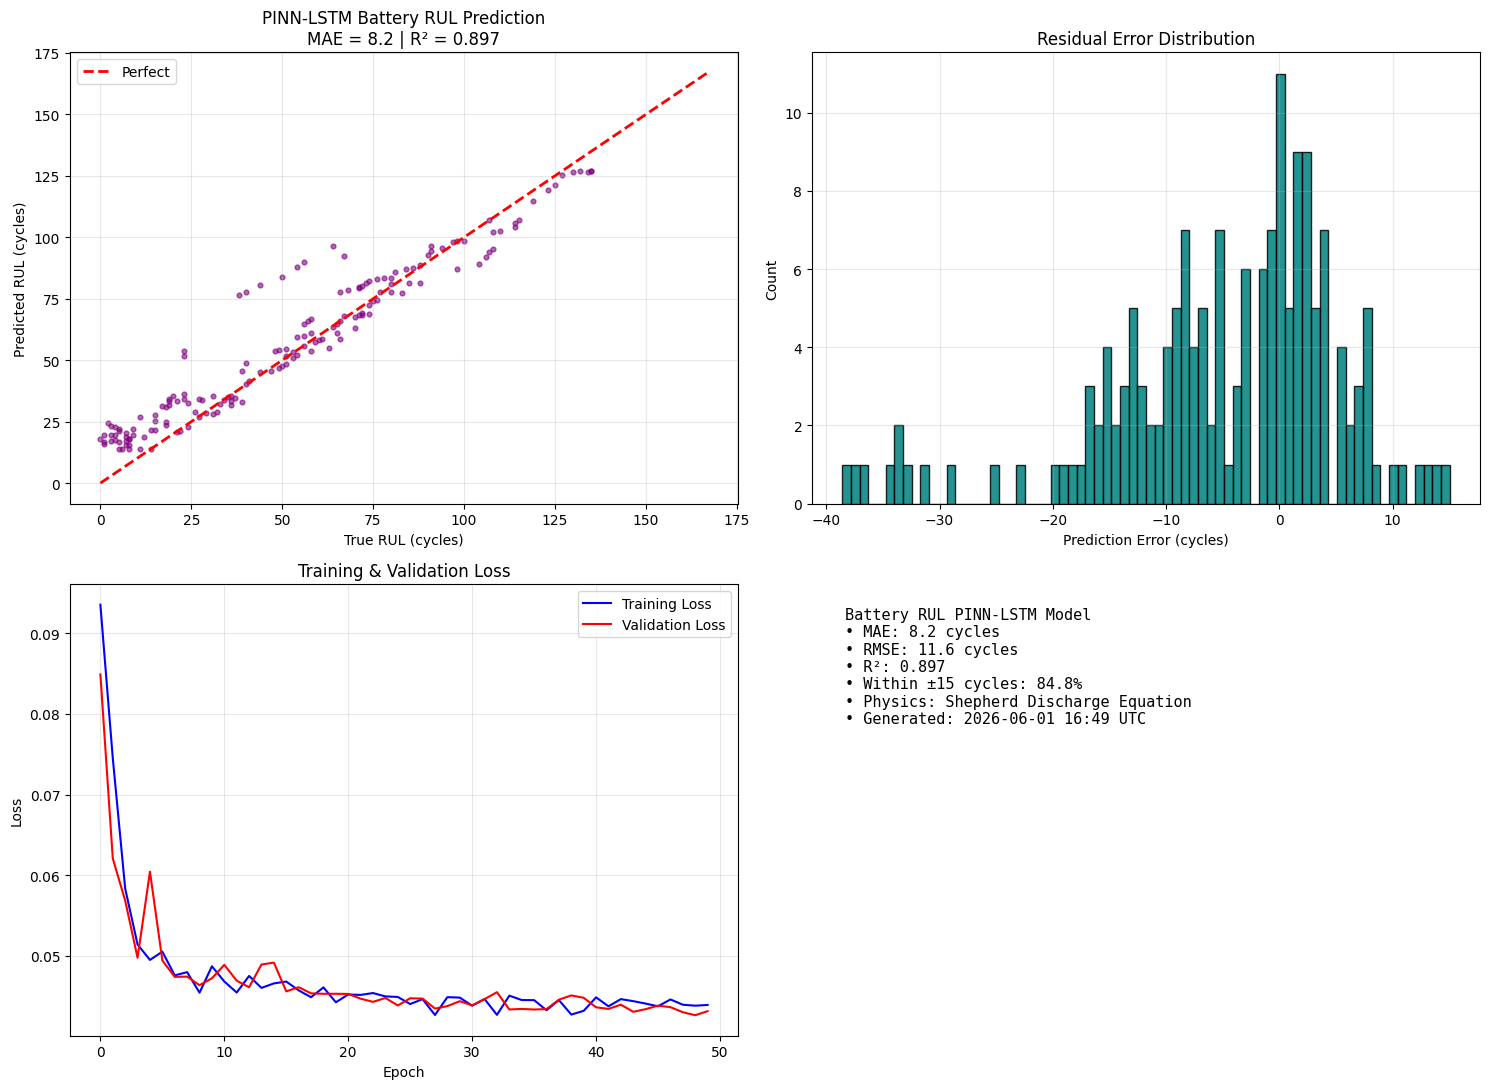

✅ All files saved to models folder!


In [46]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODELS_DIR = Path(r"D:\Vibe Coding\TwinPacemaker\models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Predictions
y_pred_norm = model.predict(X_test, verbose=0).squeeze()
y_pred = y_pred_norm * RUL_MAX
y_true = y_test * RUL_MAX

# Metrics
mae = float(mean_absolute_error(y_true, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
r2 = float(r2_score(y_true, y_pred))
within_15 = float(np.mean(np.abs(y_true - y_pred) <= 15) * 100)

print("=" * 70)
print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.4f}")
print(f"Within ±15 cycles: {within_15:.1f}%")
print("=" * 70)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Prediction Scatter
axes[0, 0].scatter(y_true[:400], y_pred[:400], alpha=0.6, s=12, color='purple')
axes[0, 0].plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('True RUL (cycles)')
axes[0, 0].set_ylabel('Predicted RUL (cycles)')
axes[0, 0].set_title(f'PINN-LSTM Battery RUL Prediction\nMAE = {mae:.1f} | R² = {r2:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
axes[0, 1].hist(y_true - y_pred, bins=70, color='teal', edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Prediction Error (cycles)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Error Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Training + Validation Loss
if 'history' in globals():
    axes[1, 0].plot(history['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history:
        axes[1, 0].plot(history['val_loss'], label='Validation Loss', color='red')
    axes[1, 0].set_title('Training & Validation Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No history available', ha='center', va='center')

# 4. Info
axes[1, 1].axis('off')
info_text = f"""Battery RUL PINN-LSTM Model
• MAE: {mae:.1f} cycles
• RMSE: {rmse:.1f} cycles
• R²: {r2:.3f}
• Within ±15 cycles: {within_15:.1f}%
• Physics: Shepherd Discharge Equation
• Generated: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}
"""
axes[1, 1].text(0.05, 0.95, info_text, transform=axes[1, 1].transAxes, 
                fontsize=11, va='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig(MODELS_DIR / "battery_pinn_results.png", dpi=200, bbox_inches='tight')
plt.show()

# Save model + info
model.save(MODELS_DIR / "battery_pinn_lstm.keras")

info = {
    "model_name": "Battery RUL PINN-LSTM",
    "metrics": {"mae": round(mae,2), "rmse": round(rmse,2), "r2": round(r2,4)},
    "generated_at": datetime.now(timezone.utc).isoformat()
}

with open(MODELS_DIR / "battery_rul_model_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("✅ All files saved to models folder!")